# Лабораторная работа 4 — Регрессия
**Датасет:** `cars_cleaned.csv` | **Цель:** `price_usd` (цена автомобиля в долларах)

**Метрики оценки:** R² · MAE · MSE · RMSE

---
### Структура ноутбука
| Раздел | Содержание |
|--------|----------|
| 0 | Импорты и константы |
| 1 | Загрузка данных |
| 2 | Разделение данных (Holdout + K-Fold) |
| 3.1 | DecisionTreeRegressor + подбор гиперпараметров 3 способами |
| 3.2 | Ансамбли sklearn (Bagging, RF, GBT, AdaBoost, Stacking) |
| 3.3 | CatBoost · XGBoost · LightGBM |
| 4 | Визуализация дерева решений и важность признаков |
| 5 | Итоговые таблицы результатов |
| 6 | Сравнение с PyCaret |
| 7 | Вывод |


## Раздел 0. Импорты и константы

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import randint, uniform

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

from sklearn.ensemble import (BaggingRegressor, RandomForestRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor,
                               StackingRegressor)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, KFold,
                                      cross_val_predict, cross_validate,
                                      cross_val_score)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.pipeline import Pipeline

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42

## Вспомогательные функции

In [64]:
def eval_reg(model, name, X_train, y_train, X_test, y_test, results):
    """
    Вычисляет R2, MAE, MSE, RMSE на train и test.
    Добавляет строку в results и выводит сводную таблицу через pd.DataFrame.
    """
    yt = model.predict(X_train)
    yp = model.predict(X_test)

    tr_r2   = round(r2_score(y_train, yt), 4)
    tr_mae  = round(mean_absolute_error(y_train, yt), 4)
    tr_mse  = round(mean_squared_error(y_train, yt), 4)
    tr_rmse = round(np.sqrt(tr_mse), 4)

    te_r2   = round(r2_score(y_test, yp), 4)
    te_mae  = round(mean_absolute_error(y_test, yp), 4)
    te_mse  = round(mean_squared_error(y_test, yp), 4)
    te_rmse = round(np.sqrt(te_mse), 4)

    results.append({
        'Algorithm':  name,
        'Train R2':   tr_r2,
        'Train MAE':  tr_mae,
        'Train MSE':  tr_mse,
        'Train RMSE': tr_rmse,
        'Test R2':    te_r2,
        'Test MAE':   te_mae,
        'Test MSE':   te_mse,
        'Test RMSE':  te_rmse,
    })

    summary = pd.DataFrame([
        {'Split': 'Train', 'R2': tr_r2, 'MAE': tr_mae, 'MSE': tr_mse, 'RMSE': tr_rmse},
        {'Split': 'Test',  'R2': te_r2, 'MAE': te_mae, 'MSE': te_mse, 'RMSE': te_rmse},
    ]).set_index('Split')

    print(f'\nОтчёт регрессии: {name}')
    display(summary.style.format('{:.4f}'))

In [65]:
def kfold_reg(model, name, X, y, cv, results):
    """
    cross_validate с scoring=['r2','neg_mean_absolute_error','neg_mean_squared_error'],
    return_train_score=True. RMSE считается как sqrt(MSE).
    Добавляет средние значений в results.
    """
    cv_res = cross_validate(
        model, X, y, cv=cv,
        scoring=['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'],
        return_train_score=True, n_jobs=-1
    )

    tr_r2   = round(cv_res['train_r2'].mean(), 4)
    tr_mae  = round(-cv_res['train_neg_mean_absolute_error'].mean(), 4)
    tr_mse  = round(-cv_res['train_neg_mean_squared_error'].mean(), 4)
    tr_rmse = round(np.sqrt(tr_mse), 4)

    te_r2   = round(cv_res['test_r2'].mean(), 4)
    te_mae  = round(-cv_res['test_neg_mean_absolute_error'].mean(), 4)
    te_mse  = round(-cv_res['test_neg_mean_squared_error'].mean(), 4)
    te_rmse = round(np.sqrt(te_mse), 4)

    results.append({
        'Algorithm':  name,
        'Train R2':   tr_r2,
        'Train MAE':  tr_mae,
        'Train MSE':  tr_mse,
        'Train RMSE': tr_rmse,
        'Test R2':    te_r2,
        'Test MAE':   te_mae,
        'Test MSE':   te_mse,
        'Test RMSE':  te_rmse,
    })
    print(f'{name}  |  CV R2={te_r2:.4f}  MAE={te_mae:.4f}  RMSE={te_rmse:.4f}')

In [66]:
def tune_model_3ways(model_cls, model_kwargs,
                     param_grid, param_dist, suggest_fn,
                     X_train, y_train, X_val, y_val,
                     n_iter=20, n_trials=30):
    """
    Подбирает гиперпараметры тремя способами:
      1. GridSearchCV        — cv=5, scoring='r2', refit=True
      2. RandomizedSearchCV  — cv=5, scoring='r2', refit=True
      3. Optuna (TPE)        — прямая оптимизация r2_score на X_val, maximize

    Победитель выбирается по R2 на X_val.
    Выводит сравнительную таблицу и возвращает лучшую модель.
    """
    candidates = {}

    # 1. GridSearchCV
    grid = GridSearchCV(
        model_cls(**model_kwargs), param_grid,
        cv=5, scoring='r2', n_jobs=-1, refit=True
    )
    grid.fit(X_train, y_train)
    candidates['GridSearchCV'] = {
        'params':    grid.best_params_,
        'val_score': r2_score(y_val, grid.best_estimator_.predict(X_val)),
        'model':     grid.best_estimator_,
    }

    # 2. RandomizedSearchCV
    rand = RandomizedSearchCV(
        model_cls(**model_kwargs), param_dist,
        n_iter=n_iter, cv=5, scoring='r2',
        n_jobs=-1, random_state=RANDOM_STATE, refit=True
    )
    rand.fit(X_train, y_train)
    candidates['RandomizedSearchCV'] = {
        'params':    rand.best_params_,
        'val_score': r2_score(y_val, rand.best_estimator_.predict(X_val)),
        'model':     rand.best_estimator_,
    }

    # 3. Optuna TPE — прямая оптимизация R2 на валидационной выборке
    def objective(trial):
        m = model_cls(**{**model_kwargs, **suggest_fn(trial)})
        m.fit(X_train, y_train)
        return r2_score(y_val, m.predict(X_val))

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    opt_model = model_cls(**{**model_kwargs, **study.best_params})
    opt_model.fit(X_train, y_train)
    candidates['Optuna (TPE)'] = {
        'params':    study.best_params,
        'val_score': r2_score(y_val, opt_model.predict(X_val)),
        'model':     opt_model,
    }

    # Сравнительная таблица
    df_cmp = pd.DataFrame([
        {'Метод': k, 'Val R2': round(v['val_score'], 4), 'Параметры': str(v['params'])}
        for k, v in candidates.items()
    ])
    with pd.option_context('display.max_colwidth', 120):
        display(
            df_cmp.style
            .highlight_max(subset=['Val R2'], color='#00E67788')
            .highlight_min(subset=['Val R2'], color='#FF52526F')
            .format({'Val R2': '{:.4f}'})
        )

    best_name = max(candidates, key=lambda k: candidates[k]['val_score'])
    best_model = candidates[best_name]['model']
    print(f'Победитель: {best_name}  (Val R2 = {candidates[best_name]["val_score"]:.4f})')
    return best_model

In [67]:
def tune_kfold_pipeline(model_cls, model_kwargs,
                          param_grid, param_dist, suggest_fn,
                          X, y, cv, n_iter=10, n_trials=15, n_jobs=-1):
    """
    Подбор гиперпараметров для K-Fold через Pipeline (без SMOTE — просто обёртка reg).
    inner_cv = KFold(n_splits=3, shuffle=True).
    Поиск: RandomizedSearchCV + Optuna на inner_cv.
    Победитель по R2. OOF через cross_val_predict на полном cv.
    Возвращает (best_pipe, best_oof).
    n_jobs контролирует параллелизм (1 для GPU-моделей).
    """
    pipe_dist = {f'reg__{k}': v for k, v in param_dist.items()}
    inner_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def make_pipe(**kw):
        return Pipeline([('reg', model_cls(**{**model_kwargs, **kw}))])

    # 1. RandomizedSearchCV (inner_cv = 3-fold)
    rscv = RandomizedSearchCV(
        make_pipe(), pipe_dist,
        n_iter=n_iter, cv=inner_cv, scoring='r2',
        n_jobs=n_jobs, random_state=RANDOM_STATE, refit=True
    )
    rscv.fit(X, y)

    # 2. Optuna (inner_cv в objective)
    def objective(trial):
        return cross_val_score(
            make_pipe(**suggest_fn(trial)), X, y,
            cv=inner_cv, scoring='r2', n_jobs=n_jobs
        ).mean()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    opt_pipe = make_pipe(**study.best_params)
    opt_pipe.fit(X, y)

    candidates = {
        'RandomizedSearchCV': (rscv.best_score_,  rscv.best_estimator_),
        'Optuna (TPE)':       (study.best_value,   opt_pipe),
    }
    df_cmp = pd.DataFrame([
        {'Метод': k, 'CV R2 (3-fold)': round(v[0], 4)}
        for k, v in candidates.items()
    ])
    with pd.option_context('display.max_colwidth', 80):
        display(df_cmp)

    best_name = max(candidates, key=lambda k: candidates[k][0])
    best_pipe  = candidates[best_name][1]
    print(f'Победитель: {best_name}  (CV R2 = {candidates[best_name][0]:.4f})')

    best_oof = cross_val_predict(best_pipe, X, y, cv=cv, n_jobs=n_jobs)
    return best_pipe, best_oof

In [68]:
def _kfold_append(name, oof, y, results):
    """
    Считает метрики по OOF-предсказаниям и добавляет строку в results.
    Train-метрики = nan (OOF — честная оценка без явного train/test).
    """
    r2_val  = round(r2_score(y, oof), 4)
    mae_val = round(mean_absolute_error(y, oof), 4)
    mse_val = round(mean_squared_error(y, oof), 4)
    rmse_val = round(np.sqrt(mse_val), 4)
    results.append({
        'Algorithm':  name,
        'Train R2':   float('nan'),
        'Train MAE':  float('nan'),
        'Train MSE':  float('nan'),
        'Train RMSE': float('nan'),
        'Test R2':    r2_val,
        'Test MAE':   mae_val,
        'Test MSE':   mse_val,
        'Test RMSE':  rmse_val,
    })
    print(f'{name}  |  OOF R2={r2_val:.4f}  MAE={mae_val:.4f}  RMSE={rmse_val:.4f}')

## Раздел 1. Загрузка данных

In [69]:
df = pd.read_csv('cars_cleaned.csv')

X = df.drop('price_usd', axis=1)
y = df['price_usd']

print(f'Размер датасета: {df.shape}')
print(f'Количество признаков: {X.shape[1]}')
print(f'\nПризнаки: {list(X.columns)}')
print(f'\nЦелевая переменная: price_usd')
print(f'  Среднее:  {y.mean():.2f}')
print(f'  Медиана:  {y.median():.2f}')
print(f'  Std:      {y.std():.2f}')
print(f'  Min/Max:  {y.min():.2f} / {y.max():.2f}')

Размер датасета: (38491, 48)
Количество признаков: 47

Признаки: ['manufacturer_name', 'transmission', 'odometer_value', 'year_produced', 'engine_has_gas', 'engine_capacity', 'has_warranty', 'state', 'drivetrain', 'is_exchangeable', 'number_of_photos', 'up_counter', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'duration_listed', 'loc_Брестская обл.', 'loc_Витебская обл.', 'loc_Гомельская обл.', 'loc_Гродненская обл.', 'loc_Минская обл.', 'loc_Могилевская обл.', 'body_cabriolet', 'body_coupe', 'body_hatchback', 'body_liftback', 'body_limousine', 'body_minibus', 'body_minivan', 'body_pickup', 'body_sedan', 'body_suv', 'body_universal', 'body_van', 'fuel_diesel', 'fuel_electric', 'fuel_gas', 'fuel_gasoline', 'fuel_hybrid-diesel', 'fuel_hybrid-petrol']

Целевая переменная: price_usd
  Среднее:  6632.81
  Медиана:  4800.00
  Std:      6424.03
  Min/Max:  1.00 / 50000.00


## Раздел 2. Разделение данных

Датасет делится двумя способами:
- **Holdout**: train 60% / val 20% / test 20%  
  Поскольку `price_usd` — непрерывная переменная, для стратификации  
  используем `pd.qcut(y, q=5, labels=False, duplicates='drop')` — разбиваем цену  
  на 5 квантильных бинов.
- **K-Fold**: k=10, `KFold(shuffle=True)`, оценка через OOF-предсказания

In [70]:
# Стратификация по квантильным бинам целевой переменной
strat_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

# Holdout: 60% train / 20% val / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=strat_bins
)
strat_temp = pd.qcut(y_temp, q=5, labels=False, duplicates='drop')
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=strat_temp
)

print('Holdout разбивка:')
print(f'  Train: {len(X_train):6d} ({len(X_train)/len(X)*100:.1f}%)  |  '
      f'price_usd: mean={y_train.mean():.0f}, std={y_train.std():.0f}')
print(f'  Val:   {len(X_val):6d} ({len(X_val)/len(X)*100:.1f}%)  |  '
      f'price_usd: mean={y_val.mean():.0f}, std={y_val.std():.0f}')
print(f'  Test:  {len(X_test):6d} ({len(X_test)/len(X)*100:.1f}%)  |  '
      f'price_usd: mean={y_test.mean():.0f}, std={y_test.std():.0f}')

Holdout разбивка:
  Train:  23094 (60.0%)  |  price_usd: mean=6623, std=6393
  Val:     7698 (20.0%)  |  price_usd: mean=6610, std=6328
  Test:    7699 (20.0%)  |  price_usd: mean=6685, std=6610


In [71]:
# K-Fold (k=10) для оценки через OOF-предсказания
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
X_full, y_full = X, y

# Накопители результатов
results_holdout = []  # holdout-метрики
results_kfold   = []  # kfold-метрики (OOF)

## Раздел 3.1. DecisionTreeRegressor

### Как работает дерево решений для регрессии?
Алгоритм **CART** рекурсивно делит пространство признаков на прямоугольные области.
В каждом узле выбирается признак и порог, минимизирующий **MSE** в дочерних узлах.
Лист предсказывает **среднее значение** целевой переменной в нём.

| Параметр | Влияние |
|----------|---------|
| `max_depth` | Глубина: маленькое → недообучение, большое → переобучение |
| `min_samples_split` | Минимум объектов для разделения → регуляризация |
| `min_samples_leaf` | Минимум объектов в листе → более сглаженные предсказания |

In [72]:
dt_param_grid = {
    'max_depth':         [5, 10, 15],
    'min_samples_split': [2, 10],
    'min_samples_leaf':  [1, 5],
}
dt_param_dist = {
    'max_depth':         randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
}
def dt_suggest(trial):
    return {
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
    }

dt_kwargs = {'random_state': RANDOM_STATE}

print('DecisionTreeRegressor — подбор гиперпараметров тремя способами')
best_dt = tune_model_3ways(
    DecisionTreeRegressor, dt_kwargs,
    dt_param_grid, dt_param_dist, dt_suggest,
    X_train, y_train, X_val, y_val,
    n_iter=10, n_trials=15,
)

# Финальная оценка на test
eval_reg(best_dt, 'DecisionTree (best)', X_train, y_train, X_test, y_test, results_holdout)

DecisionTreeRegressor — подбор гиперпараметров тремя способами


,Метод,Val R2,Параметры
0,GridSearchCV,0.8666,"{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}"
1,RandomizedSearchCV,0.8688,"{'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 4}"
2,Optuna (TPE),0.8683,"{'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 8}"


Победитель: RandomizedSearchCV  (Val R2 = 0.8688)

Отчёт регрессии: DecisionTree (best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9036,1239.9335,3941748.3758,1985.3837
Test,0.8598,1485.6163,6123714.5174,2474.6140


In [73]:
# K-Fold: подбор гиперпараметров внутри пайплайна + OOF
dt_kf_pipe, dt_kf_oof = tune_kfold_pipeline(
    DecisionTreeRegressor, dt_kwargs,
    dt_param_grid, dt_param_dist, dt_suggest,
    X_full, y_full, kf, n_iter=10, n_trials=15,
)
_kfold_append('DecisionTree (KFold)', dt_kf_oof, y_full, results_kfold)

,Метод,CV R2 (3-fold)
0,RandomizedSearchCV,0.8645
1,Optuna (TPE),0.8641


Победитель: RandomizedSearchCV  (CV R2 = 0.8645)
DecisionTree (KFold)  |  OOF R2=0.8678  MAE=1389.3878  RMSE=2336.0593


## Раздел 3.2. Ансамбли sklearn

Ансамблевые методы объединяют несколько деревьев решений для снижения дисперсии или смещения.

### BaggingRegressor

Bootstrap AGGregatING — параллельный ансамбль. Снижает дисперсию через усреднение предсказаний
множества деревьев, обученных на бутстрап-подвыборках.

In [74]:
bag_param_grid = {
    'n_estimators': [50, 100],
    'max_samples':  [0.7, 1.0],
    'max_features': [0.7, 1.0],
}
bag_param_dist = {
    'n_estimators': randint(30, 150),
    'max_samples':  uniform(0.5, 0.5),
    'max_features': uniform(0.5, 0.5),
}
def bag_suggest(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 30, 150),
        'max_samples':  trial.suggest_float('max_samples', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
    }

bag_kwargs = {
    'estimator':    DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'random_state': RANDOM_STATE,
    'n_jobs':       -1,
}

print('BaggingRegressor — подбор гиперпараметров тремя способами')
best_bag = tune_model_3ways(
    BaggingRegressor, bag_kwargs,
    bag_param_grid, bag_param_dist, bag_suggest,
    X_train, y_train, X_val, y_val,
    n_iter=10, n_trials=15,
)
eval_reg(best_bag, 'BaggingRegressor (best)', X_train, y_train, X_test, y_test, results_holdout)

# K-Fold
bag_kf_pipe, bag_kf_oof = tune_kfold_pipeline(
    BaggingRegressor, bag_kwargs,
    bag_param_grid, bag_param_dist, bag_suggest,
    X_full, y_full, kf, n_iter=10, n_trials=15,
)
_kfold_append('BaggingRegressor (KFold)', bag_kf_oof, y_full, results_kfold)

BaggingRegressor — подбор гиперпараметров тремя способами


,Метод,Val R2,Параметры
0,GridSearchCV,0.9001,"{'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 100}"
1,RandomizedSearchCV,0.9024,"{'max_features': 0.8898455001363846, 'max_samples': 0.7984250789732434, 'n_estimators': 112}"
2,Optuna (TPE),0.9034,"{'n_estimators': 147, 'max_samples': 0.9978814850328271, 'max_features': 0.8736970936526043}"


Победитель: Optuna (TPE)  (Val R2 = 0.9034)

Отчёт регрессии: BaggingRegressor (best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9374,1079.2688,2559241.6313,1599.7630
Test,0.8933,1308.8360,4663290.9025,2159.4654


,Метод,CV R2 (3-fold)
0,RandomizedSearchCV,0.8956
1,Optuna (TPE),0.8958


Победитель: Optuna (TPE)  (CV R2 = 0.8958)
BaggingRegressor (KFold)  |  OOF R2=0.8971  MAE=1266.2434  RMSE=2060.2141


### RandomForestRegressor

Улучшенный Bagging: случайный выбор признаков в каждом узле → менее коррелированные деревья →
ниже дисперсия ансамбля.

In [75]:
rf_param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [5, 8, 12],
    'min_samples_split': [2, 10],
    'max_features':      ['sqrt', 'log2'],
}
rf_param_dist = {
    'n_estimators':      randint(50, 300),
    'max_depth':         randint(3, 12),
    'min_samples_split': randint(2, 20),
    'max_features':      ['sqrt', 'log2'],
}
def rf_suggest(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 300),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

rf_kwargs = {'random_state': RANDOM_STATE, 'n_jobs': -1}

print('RandomForestRegressor — подбор гиперпараметров тремя способами')
best_rf = tune_model_3ways(
    RandomForestRegressor, rf_kwargs,
    rf_param_grid, rf_param_dist, rf_suggest,
    X_train, y_train, X_val, y_val,
    n_iter=10, n_trials=20,
)
eval_reg(best_rf, 'RandomForestRegressor (best)', X_train, y_train, X_test, y_test, results_holdout)

# K-Fold
rf_kf_pipe, rf_kf_oof = tune_kfold_pipeline(
    RandomForestRegressor, rf_kwargs,
    rf_param_grid, rf_param_dist, rf_suggest,
    X_full, y_full, kf, n_iter=10, n_trials=15,
)
_kfold_append('RandomForestRegressor (KFold)', rf_kf_oof, y_full, results_kfold)

RandomForestRegressor — подбор гиперпараметров тремя способами


,Метод,Val R2,Параметры
0,GridSearchCV,0.8680,"{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}"
1,RandomizedSearchCV,0.8491,"{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 153}"
2,Optuna (TPE),0.8620,"{'n_estimators': 144, 'max_depth': 12, 'min_samples_split': 15, 'max_features': 'sqrt'}"


Победитель: GridSearchCV  (Val R2 = 0.8680)

Отчёт регрессии: RandomForestRegressor (best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9156,1224.1307,3448201.4313,1856.9333
Test,0.8633,1483.4716,5972952.8418,2443.9625


,Метод,CV R2 (3-fold)
0,RandomizedSearchCV,0.8431
1,Optuna (TPE),0.8571


Победитель: Optuna (TPE)  (CV R2 = 0.8571)
RandomForestRegressor (KFold)  |  OOF R2=0.8587  MAE=1479.5335  RMSE=2414.7097


### GradientBoostingRegressor

Последовательный ансамбль: каждое следующее дерево обучается на остатках предыдущего.
`subsample < 1.0` (Stochastic GBT) — регуляризация через подвыборку объектов.

> **Примечание:** `GradientBoostingRegressor` не поддерживает параметр `n_jobs`.

In [76]:
gbc_param_grid = {
    'n_estimators':  [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 4],
    'subsample':     [0.7, 0.9],
}
gbc_param_dist = {
    'n_estimators':  randint(50, 200),
    'learning_rate': uniform(0.02, 0.18),
    'max_depth':     randint(2, 6),
    'subsample':     uniform(0.6, 0.3),
}
def gbc_suggest(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
        'max_depth':     trial.suggest_int('max_depth', 2, 6),
        'subsample':     trial.suggest_float('subsample', 0.6, 0.9),
    }

gbc_kwargs = {'random_state': RANDOM_STATE}  # n_jobs не поддерживается

print('GradientBoostingRegressor — подбор гиперпараметров тремя способами')
best_gbc = tune_model_3ways(
    GradientBoostingRegressor, gbc_kwargs,
    gbc_param_grid, gbc_param_dist, gbc_suggest,
    X_train, y_train, X_val, y_val,
    n_iter=5, n_trials=10,
)
eval_reg(best_gbc, 'GradientBoostingRegressor (best)', X_train, y_train, X_test, y_test, results_holdout)

# K-Fold
gbc_kf_pipe, gbc_kf_oof = tune_kfold_pipeline(
    GradientBoostingRegressor, gbc_kwargs,
    gbc_param_grid, gbc_param_dist, gbc_suggest,
    X_full, y_full, kf, n_iter=5, n_trials=10,
)
_kfold_append('GradientBoostingRegressor (KFold)', gbc_kf_oof, y_full, results_kfold)

GradientBoostingRegressor — подбор гиперпараметров тремя способами


,Метод,Val R2,Параметры
0,GridSearchCV,0.9090,"{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.9}"
1,RandomizedSearchCV,0.9080,"{'learning_rate': 0.1277585271554666, 'max_depth': 4, 'n_estimators': 171, 'subsample': 0.6467983561008608}"
2,Optuna (TPE),0.9119,"{'n_estimators': 59, 'learning_rate': 0.1777933581403786, 'max_depth': 6, 'subsample': 0.8425192044349383}"


Победитель: Optuna (TPE)  (Val R2 = 0.9119)

Отчёт регрессии: GradientBoostingRegressor (best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9434,1039.5955,2315315.6727,1521.6161
Test,0.8990,1269.0337,4412977.5596,2100.7088


,Метод,CV R2 (3-fold)
0,RandomizedSearchCV,0.9035
1,Optuna (TPE),0.9034


Победитель: RandomizedSearchCV  (CV R2 = 0.9035)
GradientBoostingRegressor (KFold)  |  OOF R2=0.9038  MAE=1237.7821  RMSE=1991.9451


### AdaBoostRegressor

Адаптивный бустинг: повышает веса объектов с большой ошибкой на каждой итерации.
Базовая модель — `DecisionTreeRegressor(max_depth=3)` (слабый регрессор).

> **Примечание:** `AdaBoostRegressor` не поддерживает параметр `n_jobs`.

In [77]:
ada_param_grid = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.5, 1.0],
}
ada_param_dist = {
    'n_estimators':  randint(30, 250),
    'learning_rate': uniform(0.1, 1.9),
}
def ada_suggest(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 30, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.1, 2.0),
    }

ada_kwargs = {
    'estimator':    DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'random_state': RANDOM_STATE,
    # n_jobs не поддерживается
}

print('AdaBoostRegressor — подбор гиперпараметров тремя способами')
best_ada = tune_model_3ways(
    AdaBoostRegressor, ada_kwargs,
    ada_param_grid, ada_param_dist, ada_suggest,
    X_train, y_train, X_val, y_val,
    n_iter=5, n_trials=10,
)
eval_reg(best_ada, 'AdaBoostRegressor (best)', X_train, y_train, X_test, y_test, results_holdout)

# K-Fold
ada_kf_pipe, ada_kf_oof = tune_kfold_pipeline(
    AdaBoostRegressor, ada_kwargs,
    ada_param_grid, ada_param_dist, ada_suggest,
    X_full, y_full, kf, n_iter=5, n_trials=10,
)
_kfold_append('AdaBoostRegressor (KFold)', ada_kf_oof, y_full, results_kfold)

AdaBoostRegressor — подбор гиперпараметров тремя способами


,Метод,Val R2,Параметры
0,GridSearchCV,0.8982,"{'learning_rate': 0.5, 'n_estimators': 100}"
1,RandomizedSearchCV,0.9014,"{'learning_rate': 0.21035886311957896, 'n_estimators': 117}"
2,Optuna (TPE),0.9021,"{'n_estimators': 64, 'learning_rate': 0.39638958863878504}"


Победитель: Optuna (TPE)  (Val R2 = 0.9021)

Отчёт регрессии: AdaBoostRegressor (best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9582,996.1529,1708232.2252,1306.9936
Test,0.8920,1331.5237,4718165.7157,2172.1339


,Метод,CV R2 (3-fold)
0,RandomizedSearchCV,0.8959
1,Optuna (TPE),0.8956


Победитель: RandomizedSearchCV  (CV R2 = 0.8959)
AdaBoostRegressor (KFold)  |  OOF R2=0.8964  MAE=1346.8127  RMSE=2068.0358


### StackingRegressor

Мета-ансамбль. Базовые модели — **разных типов** (важно для стекинга!):
| Модель | Тип |
|--------|-----|
| `DecisionTreeRegressor` | Логический |
| `KNeighborsRegressor` | Метрический |
| `Ridge` | Линейный |

Мета-модель: `Ridge` — обучается на предсказаниях базовых моделей.
Параметры фиксированы (cv=5 внутри стекинга, n_jobs=1 внутри стекинга).

In [78]:
stacking_reg = StackingRegressor(
    estimators=[
        ('dt',    DecisionTreeRegressor(**best_dt.get_params())),
        ('knn',   KNeighborsRegressor(n_neighbors=7, n_jobs=1)),
        ('ridge', Ridge()),
    ],
    final_estimator=Ridge(),
    cv=5,
    n_jobs=1,  # n_jobs=1 внутри стекинга для стабильности
)

stacking_reg.fit(X_train, y_train)
eval_reg(stacking_reg, 'StackingRegressor', X_train, y_train, X_test, y_test, results_holdout)

# K-Fold: cross_val_predict напрямую (параметры не тюним)
stack_kf_oof = cross_val_predict(
    StackingRegressor(
        estimators=[
            ('dt',    DecisionTreeRegressor(**best_dt.get_params())),
            ('knn',   KNeighborsRegressor(n_neighbors=7, n_jobs=1)),
            ('ridge', Ridge()),
        ],
        final_estimator=Ridge(),
        cv=5,
        n_jobs=1,
    ),
    X_full, y_full, cv=kf, n_jobs=1
)
_kfold_append('StackingRegressor (KFold)', stack_kf_oof, y_full, results_kfold)


Отчёт регрессии: StackingRegressor


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9030,1248.9523,3966325.0212,1991.5635
Test,0.8687,1448.4902,5734426.9756,2394.6664


StackingRegressor (KFold)  |  OOF R2=0.8715  MAE=1431.5490  RMSE=2303.0872


## Раздел 3.3. Библиотеки градиентного бустинга

Все три библиотеки поддерживают GPU-ускорение:
| Библиотека | GPU параметр |
|-----------|---------------|
| **CatBoost** | `task_type='GPU'` |
| **XGBoost** | `device='cuda'` |
| **LightGBM** | `device='gpu'` |

### CatBoostRegressor

CatBoost (Яндекс). Ordered Boosting предотвращает target leakage.
Holdout: встроенный `grid_search` (cv=3, refit=False) + Optuna. Победитель по Val R2.
KFold: `tune_kfold_pipeline` с n_jobs=1 (GPU).

In [79]:
# Встроенный grid_search CatBoost
cat_base = CatBoostRegressor(random_seed=RANDOM_STATE, verbose=False, task_type='GPU')

cat_param_grid_gs = {
    'iterations':    [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth':         [4, 6],
}

print('CatBoost — встроенный grid_search (cv=3)...')
cat_grid_result = cat_base.grid_search(
    cat_param_grid_gs,
    X=X_train, y=y_train,
    cv=3,
    partition_random_seed=RANDOM_STATE,
    refit=False,
    plot=False,
    verbose=False,
)
best_cat_gs_params = cat_grid_result['params']
print(f'Лучшие параметры (GridSearch): {best_cat_gs_params}')

cat_gs_model = CatBoostRegressor(
    **best_cat_gs_params,
    random_seed=RANDOM_STATE, verbose=False, task_type='GPU'
)
cat_gs_model.fit(X_train, y_train)
gs_val_r2 = r2_score(y_val, cat_gs_model.predict(X_val))
print(f'Val R2 (GridSearch): {gs_val_r2:.4f}')

# Optuna для CatBoost
def cat_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':         trial.suggest_int('depth', 3, 7),
    }
    m = CatBoostRegressor(**params, random_seed=RANDOM_STATE, verbose=False, task_type='GPU')
    m.fit(X_train, y_train)
    return r2_score(y_val, m.predict(X_val))

cat_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cat_study.optimize(cat_objective, n_trials=15, show_progress_bar=False)
opt_val_r2 = cat_study.best_value
print(f'Val R2 (Optuna):     {opt_val_r2:.4f}')

# Выбор победителя
if opt_val_r2 > gs_val_r2:
    best_cat = CatBoostRegressor(
        **cat_study.best_params,
        random_seed=RANDOM_STATE, verbose=False, task_type='GPU'
    )
    best_cat.fit(X_train, y_train)
    print(f'Победитель: Optuna (TPE)  (Val R2 = {opt_val_r2:.4f})')
else:
    best_cat = cat_gs_model
    print(f'Победитель: GridSearch  (Val R2 = {gs_val_r2:.4f})')

eval_reg(best_cat, 'CatBoostRegressor (GPU best)', X_train, y_train, X_test, y_test, results_holdout)

CatBoost — встроенный grid_search (cv=3)...
bestTest = 2386.87494
bestIteration = 99
bestTest = 2209.232171
bestIteration = 99
bestTest = 2223.286623
bestIteration = 199
bestTest = 2114.617022
bestIteration = 199
bestTest = 2256.772808
bestIteration = 99
bestTest = 2121.06628
bestIteration = 99
bestTest = 2148.876921
bestIteration = 199
bestTest = 2064.679105
bestIteration = 191
Training on fold [0/3]
bestTest = 2059.898342
bestIteration = 196
Training on fold [1/3]
bestTest = 2022.132824
bestIteration = 199
Training on fold [2/3]
bestTest = 2108.706219
bestIteration = 199
Лучшие параметры (GridSearch): {'depth': 6, 'learning_rate': 0.1, 'iterations': 200}
Val R2 (GridSearch): 0.9112
Val R2 (Optuna):     0.9134
Победитель: Optuna (TPE)  (Val R2 = 0.9134)

Отчёт регрессии: CatBoostRegressor (GPU best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9368,1076.5418,2583818.9150,1607.4262
Test,0.9056,1237.9560,4125262.2838,2031.0742


In [80]:
cat_param_dist = {
    'iterations':    randint(100, 300),
    'learning_rate': uniform(0.01, 0.19),
    'depth':         randint(3, 8),
}

# 1. Встроенный grid_search CatBoost
cat_base = CatBoostRegressor(random_seed=RANDOM_STATE, verbose=False, task_type='GPU')
cat_param_grid_gs = {
    'iterations':    [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth':         [4, 6],
}
print('CatBoost — встроенный grid_search (cv=3)...')
cat_grid_result = cat_base.grid_search(
    cat_param_grid_gs,
    X=X_train, y=y_train,
    cv=3,
    partition_random_seed=RANDOM_STATE,
    refit=False, plot=False, verbose=False,
)
best_cat_gs_params = cat_grid_result['params']
cat_gs_model = CatBoostRegressor(
    **best_cat_gs_params,
    random_seed=RANDOM_STATE, verbose=False, task_type='GPU'
)
cat_gs_model.fit(X_train, y_train)
gs_val_r2 = r2_score(y_val, cat_gs_model.predict(X_val))
print(f'Val R2 (GridSearch): {gs_val_r2:.4f}')

# 2. RandomizedSearchCV
# CatBoost несовместим с clone() поэтому используем ручной random search
best_rand_r2 = -np.inf
best_rand_params = None
best_rand_model = None

np.random.seed(RANDOM_STATE)
for _ in range(20):
    params = {
        'iterations':    int(randint(100, 300).rvs()),
        'learning_rate': float(uniform(0.01, 0.19).rvs()),
        'depth':         int(randint(3, 8).rvs()),
    }
    m = CatBoostRegressor(**params, random_seed=RANDOM_STATE, verbose=False, task_type='GPU')
    m.fit(X_train, y_train)
    val_r2 = r2_score(y_val, m.predict(X_val))
    if val_r2 > best_rand_r2:
        best_rand_r2 = val_r2
        best_rand_params = params
        best_rand_model = m

print(f'Val R2 (RandomSearch): {best_rand_r2:.4f}')

# 3. Optuna
def cat_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':         trial.suggest_int('depth', 3, 7),
    }
    m = CatBoostRegressor(**params, random_seed=RANDOM_STATE, verbose=False, task_type='GPU')
    m.fit(X_train, y_train)
    return r2_score(y_val, m.predict(X_val))

cat_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cat_study.optimize(cat_objective, n_trials=15, show_progress_bar=False)
opt_val_r2 = cat_study.best_value
print(f'Val R2 (Optuna): {opt_val_r2:.4f}')

# Сравнительная таблица
candidates = {
    'GridSearch':   {'val_score': gs_val_r2,    'model': cat_gs_model},
    'RandomSearch': {'val_score': best_rand_r2,  'model': best_rand_model},
    'Optuna (TPE)': {'val_score': opt_val_r2,    'model': None},
}

df_cmp = pd.DataFrame([
    {'Метод': k, 'Val R2': round(v['val_score'], 4)}
    for k, v in candidates.items()
])
display(df_cmp)

# Победитель
best_cat_name = max(candidates, key=lambda k: candidates[k]['val_score'])
if best_cat_name == 'Optuna (TPE)':
    best_cat = CatBoostRegressor(
        **cat_study.best_params,
        random_seed=RANDOM_STATE, verbose=False, task_type='GPU'
    )
    best_cat.fit(X_train, y_train)
else:
    best_cat = candidates[best_cat_name]['model']

print(f'Победитель: {best_cat_name}  (Val R2 = {candidates[best_cat_name]["val_score"]:.4f})')
eval_reg(best_cat, 'CatBoostRegressor (GPU best)', X_train, y_train, X_test, y_test, results_holdout)

CatBoost — встроенный grid_search (cv=3)...
bestTest = 2386.87494
bestIteration = 99
bestTest = 2209.232171
bestIteration = 99
bestTest = 2223.286623
bestIteration = 199
bestTest = 2114.617022
bestIteration = 199
bestTest = 2256.772808
bestIteration = 99
bestTest = 2121.06628
bestIteration = 99
bestTest = 2148.876921
bestIteration = 199
bestTest = 2064.679105
bestIteration = 191
Training on fold [0/3]
bestTest = 2059.898342
bestIteration = 196
Training on fold [1/3]
bestTest = 2022.132824
bestIteration = 199
Training on fold [2/3]
bestTest = 2108.706219
bestIteration = 199
Val R2 (GridSearch): 0.9112
Val R2 (RandomSearch): 0.9152
Val R2 (Optuna): 0.9134


,Метод,Val R2
0,GridSearch,0.9112
1,RandomSearch,0.9152
2,Optuna (TPE),0.9134


Победитель: RandomSearch  (Val R2 = 0.9152)

Отчёт регрессии: CatBoostRegressor (GPU best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9439,1030.0748,2293366.9420,1514.3867
Test,0.9059,1226.3384,4112005.4672,2027.8080


### XGBRegressor

XGBoost (Chen & Guestrin). Регуляризация L1/L2, column subsampling, GPU-ускорение.

In [81]:
xgb_kwargs = {
    'random_state': RANDOM_STATE,
    'device':       'cuda',
    'verbosity':    0,
}

xgb_param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'subsample':     [0.7, 1.0],
}
xgb_param_dist = {
    'n_estimators':  randint(50, 250),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth':     randint(2, 7),
    'subsample':     uniform(0.6, 0.4),
}
def xgb_suggest(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':     trial.suggest_int('max_depth', 2, 7),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
    }

print('XGBRegressor — подбор гиперпараметров тремя способами')
best_xgb = tune_model_3ways(
    XGBRegressor, xgb_kwargs,
    xgb_param_grid, xgb_param_dist, xgb_suggest,
    X_train, y_train, X_val, y_val,
    n_iter=10, n_trials=15,
)
eval_reg(best_xgb, 'XGBRegressor (GPU best)', X_train, y_train, X_test, y_test, results_holdout)

# K-Fold (n_jobs=1 для GPU)
xgb_kf_pipe, xgb_kf_oof = tune_kfold_pipeline(
    XGBRegressor, xgb_kwargs,
    xgb_param_grid, xgb_param_dist, xgb_suggest,
    X_full, y_full, kf, n_iter=10, n_trials=15, n_jobs=1,
)
_kfold_append('XGBRegressor (KFold)', xgb_kf_oof, y_full, results_kfold)

XGBRegressor — подбор гиперпараметров тремя способами


,Метод,Val R2,Параметры
0,GridSearchCV,0.9103,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}"
1,RandomizedSearchCV,0.9085,"{'learning_rate': 0.16703519227860275, 'max_depth': 4, 'n_estimators': 157, 'subsample': 0.8056937753654446}"
2,Optuna (TPE),0.9146,"{'n_estimators': 239, 'learning_rate': 0.04128697297312281, 'max_depth': 7, 'subsample': 0.8559192772506938}"


Победитель: Optuna (TPE)  (Val R2 = 0.9146)

Отчёт регрессии: XGBRegressor (GPU best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9549,937.0819,1842553.4099,1357.4069
Test,0.9059,1216.8212,4112097.2271,2027.8307


,Метод,CV R2 (3-fold)
0,RandomizedSearchCV,0.9051
1,Optuna (TPE),0.9101


Победитель: Optuna (TPE)  (CV R2 = 0.9101)
XGBRegressor (KFold)  |  OOF R2=0.9106  MAE=1173.5472  RMSE=1921.2844


### LGBMRegressor

LightGBM (Microsoft). Leaf-wise рост дерева + гистограммный метод = самый быстрый бустинг.

In [82]:
lgbm_kwargs = {
    'random_state': RANDOM_STATE,
    'n_jobs':       1,
    'device':       'gpu',
    'verbose':      -1,
}

lgbm_param_grid = {
    'n_estimators':  [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'num_leaves':    [15, 31],
}
lgbm_param_dist = {
    'n_estimators':  randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth':     randint(3, 6),
    'num_leaves':    randint(10, 50),
}
def lgbm_suggest(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 6),
        'num_leaves':    trial.suggest_int('num_leaves', 10, 50),
    }

print('LGBMRegressor — подбор гиперпараметров тремя способами')
best_lgbm = tune_model_3ways(
    LGBMRegressor, lgbm_kwargs,
    lgbm_param_grid, lgbm_param_dist, lgbm_suggest,
    X_train, y_train, X_val, y_val,
    n_iter=10, n_trials=15,
)
eval_reg(best_lgbm, 'LGBMRegressor (GPU best)', X_train, y_train, X_test, y_test, results_holdout)

# K-Fold (n_jobs=1 для GPU)
lgbm_kf_pipe, lgbm_kf_oof = tune_kfold_pipeline(
    LGBMRegressor, lgbm_kwargs,
    lgbm_param_grid, lgbm_param_dist, lgbm_suggest,
    X_full, y_full, kf, n_iter=10, n_trials=15, n_jobs=1,
)
_kfold_append('LGBMRegressor (KFold)', lgbm_kf_oof, y_full, results_kfold)

LGBMRegressor — подбор гиперпараметров тремя способами


,Метод,Val R2,Параметры
0,GridSearchCV,0.9117,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'num_leaves': 31}"
1,RandomizedSearchCV,0.9132,"{'learning_rate': 0.12973169683940733, 'max_depth': 5, 'n_estimators': 171, 'num_leaves': 28}"
2,Optuna (TPE),0.9123,"{'n_estimators': 114, 'learning_rate': 0.19888339471605376, 'max_depth': 6, 'num_leaves': 43}"


Победитель: RandomizedSearchCV  (Val R2 = 0.9132)

Отчёт регрессии: LGBMRegressor (GPU best)


,R2,MAE,MSE,RMSE
Split,,,,
Train,0.9312,1092.9986,2811541.9339,1676.7653
Test,0.9052,1248.7657,4140338.0306,2034.7821


,Метод,CV R2 (3-fold)
0,RandomizedSearchCV,0.9065
1,Optuna (TPE),0.9056


Победитель: RandomizedSearchCV  (CV R2 = 0.9065)
LGBMRegressor (KFold)  |  OOF R2=0.9079  MAE=1206.9055  RMSE=1949.8604


## Раздел 4. Визуализация дерева решений

Визуализируем лучшее дерево решений из раздела 3.1.

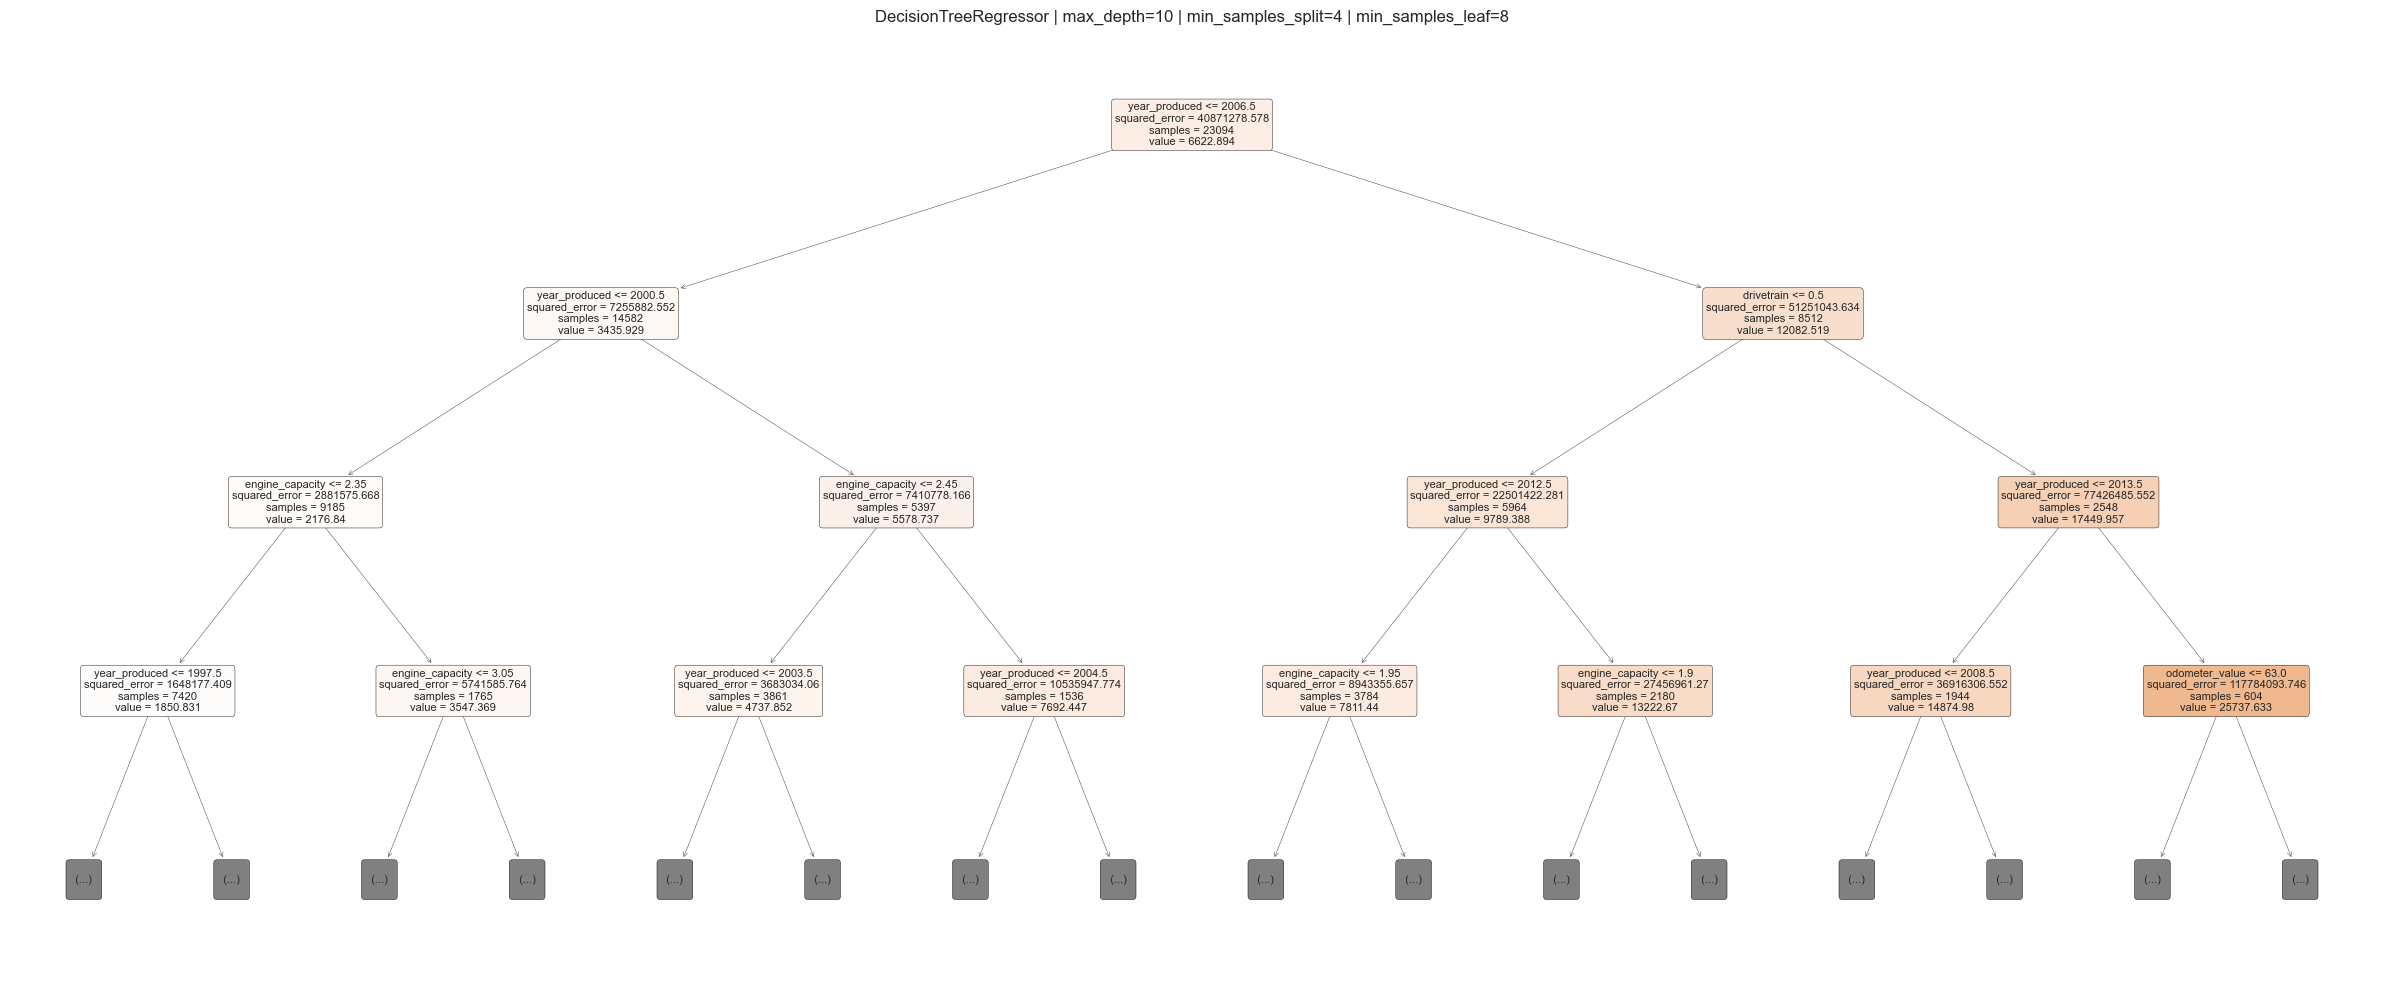

In [83]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    best_dt,
    feature_names=X.columns.tolist(),
    filled=True, rounded=True,
    max_depth=3, ax=ax, fontsize=8
)
plt.title(
    f'DecisionTreeRegressor | max_depth={best_dt.max_depth} | '
    f'min_samples_split={best_dt.min_samples_split} | '
    f'min_samples_leaf={best_dt.min_samples_leaf}',
    fontsize=12
)
plt.tight_layout()
plt.show()

In [84]:
rules = export_text(best_dt, feature_names=X.columns.tolist(), max_depth=4)
print('Решающие правила DecisionTreeRegressor (max_depth=4):')
print(rules)

Решающие правила DecisionTreeRegressor (max_depth=4):
|--- year_produced <= 2006.50
|   |--- year_produced <= 2000.50
|   |   |--- engine_capacity <= 2.35
|   |   |   |--- year_produced <= 1997.50
|   |   |   |   |--- engine_capacity <= 1.85
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- engine_capacity >  1.85
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- year_produced >  1997.50
|   |   |   |   |--- manufacturer_name <= 1.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- manufacturer_name >  1.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |--- engine_capacity >  2.35
|   |   |   |--- engine_capacity <= 3.05
|   |   |   |   |--- year_produced <= 1995.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- year_produced >  1995.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- engine_capacity >  3.05
|   |   |   |   |--- year_produced <= 1985.50
| 

In [85]:
fi = pd.Series(best_dt.feature_importances_, index=X.columns)
fi = fi[fi > 0].sort_values(ascending=False).head(20)

print('\nТоп-10 признаков по важности:')
display(fi.head(10).to_frame('Importance').style.format('{:.4f}'))


Топ-10 признаков по важности:


,Importance
year_produced,0.6821
drivetrain,0.1321
engine_capacity,0.0826
odometer_value,0.0359
manufacturer_name,0.0252
fuel_diesel,0.0074
transmission,0.0069
body_minibus,0.0045
feature_8,0.0039
number_of_photos,0.0026


## Раздел 5. Итоговые таблицы результатов


In [86]:
print('РЕГРЕССИЯ — Holdout (train 60% / val 20% / test 20%)')
print('Зелёный = лучший, красный = худший | R2: выше лучше | MAE/MSE/RMSE: ниже лучше')

df_holdout = pd.DataFrame(results_holdout).drop_duplicates(ignore_index=True)
display(
    df_holdout.style
    .highlight_max(subset=['Test R2'],                           color='#00E67788')
    .highlight_min(subset=['Test MAE', 'Test MSE', 'Test RMSE'], color='#00E67788')
    .highlight_min(subset=['Test R2'],                           color='#FF52526F')
    .highlight_max(subset=['Test MAE', 'Test MSE', 'Test RMSE'], color='#FF52526F')
    .format(precision=4)
    .set_caption('Таблица 1 (Holdout): зелёный = лучший, красный = худший по Test-метрикам')
)

РЕГРЕССИЯ — Holdout (train 60% / val 20% / test 20%)
Зелёный = лучший, красный = худший | R2: выше лучше | MAE/MSE/RMSE: ниже лучше


,Algorithm,Train R2,Train MAE,Train MSE,Train RMSE,Test R2,Test MAE,Test MSE,Test RMSE
0,DecisionTree (best),0.9036,1239.9335,3941748.3758,1985.3837,0.8598,1485.6163,6123714.5174,2474.6140
1,BaggingRegressor (best),0.9374,1079.2688,2559241.6313,1599.7630,0.8933,1308.8360,4663290.9025,2159.4654
2,RandomForestRegressor (best),0.9156,1224.1307,3448201.4313,1856.9333,0.8633,1483.4716,5972952.8418,2443.9625
3,GradientBoostingRegressor (best),0.9434,1039.5955,2315315.6727,1521.6161,0.8990,1269.0337,4412977.5596,2100.7088
4,AdaBoostRegressor (best),0.9582,996.1529,1708232.2252,1306.9936,0.8920,1331.5237,4718165.7157,2172.1339
5,StackingRegressor,0.9030,1248.9523,3966325.0212,1991.5635,0.8687,1448.4902,5734426.9756,2394.6664
6,CatBoostRegressor (GPU best),0.9368,1076.5418,2583818.9150,1607.4262,0.9056,1237.9560,4125262.2838,2031.0742
7,CatBoostRegressor (GPU best),0.9439,1030.0748,2293366.9420,1514.3867,0.9059,1226.3384,4112005.4672,2027.8080
8,XGBRegressor (GPU best),0.9549,937.0819,1842553.4099,1357.4069,0.9059,1216.8212,4112097.2271,2027.8307
9,LGBMRegressor (GPU best),0.9312,1092.9986,2811541.9339,1676.7653,0.9052,1248.7657,4140338.0306,2034.7821


In [87]:
print('РЕГРЕССИЯ — KFold (k=10) + OOF-предсказания')
print('Train-метрики = nan для OOF-моделей (нет явного train/test разделения)')

df_kfold = pd.DataFrame(results_kfold)
display(
    df_kfold.style
    .highlight_max(subset=['Test R2'],                           color='#00E67788')
    .highlight_min(subset=['Test MAE', 'Test MSE', 'Test RMSE'], color="#00E67788")
    .highlight_min(subset=['Test R2'],                           color='#FF52526F')
    .highlight_max(subset=['Test MAE', 'Test MSE', 'Test RMSE'], color="#FF52526F")
    .format(precision=4)
    .set_caption('Таблица 2 (KFold): OOF-метрики, Train = nan')
)

РЕГРЕССИЯ — KFold (k=10) + OOF-предсказания
Train-метрики = nan для OOF-моделей (нет явного train/test разделения)


,Algorithm,Train R2,Train MAE,Train MSE,Train RMSE,Test R2,Test MAE,Test MSE,Test RMSE
0,DecisionTree (KFold),nan,nan,nan,nan,0.8678,1389.3878,5457172.9906,2336.0593
1,BaggingRegressor (KFold),nan,nan,nan,nan,0.8971,1266.2434,4244482.3148,2060.2141
2,RandomForestRegressor (KFold),nan,nan,nan,nan,0.8587,1479.5335,5830823.0991,2414.7097
3,GradientBoostingRegressor (KFold),nan,nan,nan,nan,0.9038,1237.7821,3967845.0950,1991.9451
4,AdaBoostRegressor (KFold),nan,nan,nan,nan,0.8964,1346.8127,4276772.1298,2068.0358
5,StackingRegressor (KFold),nan,nan,nan,nan,0.8715,1431.5490,5304210.8515,2303.0872
6,XGBRegressor (KFold),nan,nan,nan,nan,0.9106,1173.5472,3691333.7420,1921.2844
7,LGBMRegressor (KFold),nan,nan,nan,nan,0.9079,1206.9055,3801955.4537,1949.8604


## Раздел 6. Сравнение с PyCaret

> PyCaret — low-code ML библиотека, которая автоматически сравнивает множество моделей.
> Используем её для валидации наших результатов.
> `fold=5` соответствует внутренней кросс-валидации, `train_size=0.8` — holdout-разбивке.


In [88]:
from pycaret.regression import (setup as pc_setup,
                                compare_models as pc_compare,
                                tune_model as pc_tune,
                                pull as pc_pull)

pc_setup(
    data=pd.concat([X_full, y_full], axis=1),
    target='price_usd',
    session_id=RANDOM_STATE,
    train_size=0.8,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    fold=10,
    verbose=False,
)


In [89]:
# Сравнение всех моделей — сортируем по R2
best_pc_models = pc_compare(sort='R2', n_select=3, verbose=False, 
    include=['dt', 'rf', 'gbr', 'ada', 'catboost', 'xgboost', 'lightgbm'],)
                    
pc_compare_results = pc_pull()
print('Метрики полученные с помощью pycaret')
display(pc_compare_results)

display(
    df_holdout.style
    .highlight_max(subset=['Test R2'],                           color='#00E67788')
    .highlight_min(subset=['Test MAE', 'Test MSE', 'Test RMSE'], color='#00E67788')
    .highlight_min(subset=['Test R2'],                           color='#FF52526F')
    .highlight_max(subset=['Test MAE', 'Test MSE', 'Test RMSE'], color='#FF52526F')
    .format(precision=4)
    .set_caption('Таблица 1 (Holdout): зелёный = лучший, красный = худший по Test-метрикам')
)


Метрики полученные с помощью pycaret


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,1174.7731,3.618731e+06,1899.4355,0.9127,0.3931,0.5502,1.352
lightgbm,Light Gradient Boosting Machine,1211.5680,3.794345e+06,1945.3651,0.9085,0.3963,0.5762,0.284
xgboost,Extreme Gradient Boosting,1211.7130,3.898819e+06,1971.8187,0.9060,0.3970,0.5154,0.392
rf,Random Forest Regressor,1215.0955,4.042341e+06,2007.9914,0.9025,0.3877,0.5901,1.314
gbr,Gradient Boosting Regressor,1342.4101,4.571863e+06,2135.8482,0.8897,0.4341,0.6196,0.369
dt,Decision Tree Regressor,1700.1112,7.999491e+06,2826.3220,0.8069,0.5213,0.5552,0.238
ada,AdaBoost Regressor,4525.4315,2.544808e+07,5040.4917,0.3837,1.1350,3.4483,0.244


,Algorithm,Train R2,Train MAE,Train MSE,Train RMSE,Test R2,Test MAE,Test MSE,Test RMSE
0,DecisionTree (best),0.9036,1239.9335,3941748.3758,1985.3837,0.8598,1485.6163,6123714.5174,2474.6140
1,BaggingRegressor (best),0.9374,1079.2688,2559241.6313,1599.7630,0.8933,1308.8360,4663290.9025,2159.4654
2,RandomForestRegressor (best),0.9156,1224.1307,3448201.4313,1856.9333,0.8633,1483.4716,5972952.8418,2443.9625
3,GradientBoostingRegressor (best),0.9434,1039.5955,2315315.6727,1521.6161,0.8990,1269.0337,4412977.5596,2100.7088
4,AdaBoostRegressor (best),0.9582,996.1529,1708232.2252,1306.9936,0.8920,1331.5237,4718165.7157,2172.1339
5,StackingRegressor,0.9030,1248.9523,3966325.0212,1991.5635,0.8687,1448.4902,5734426.9756,2394.6664
6,CatBoostRegressor (GPU best),0.9368,1076.5418,2583818.9150,1607.4262,0.9056,1237.9560,4125262.2838,2031.0742
7,CatBoostRegressor (GPU best),0.9439,1030.0748,2293366.9420,1514.3867,0.9059,1226.3384,4112005.4672,2027.8080
8,XGBRegressor (GPU best),0.9549,937.0819,1842553.4099,1357.4069,0.9059,1216.8212,4112097.2271,2027.8307
9,LGBMRegressor (GPU best),0.9312,1092.9986,2811541.9339,1676.7653,0.9052,1248.7657,4140338.0306,2034.7821


# Раздел 7. Вывод

В ходе лабораторной работы №4 была решена задача регрессии — предсказание цены автомобиля (`price_usd`) по датасету `cars_cleaned.csv`.

## Подготовка данных

Датасет полностью предобработан: все признаки числовые, пропущенных значений нет. Датасет содержит 47 признаков включая числовые (`odometer_value`, `engine_capacity`, `year_produced` и др.) и бинарные one-hot признаки (`body_*`, `fuel_*`, `loc_*`).

Для стратификации непрерывной целевой переменной при holdout-разделении применялся `pd.qcut(y, q=5, labels=False, duplicates='drop')` — разбиение на 5 квантильных бинов.

Данные разделялись двумя способами:
- **Holdout**: train 60% / val 20% / test 20% со стратификацией по квантильным бинам `price_usd`
- **K-Fold**: k=10, `KFold(shuffle=True, random_state=42)`, оценка через OOF-предсказания

## Подбор гиперпараметров

Для каждой модели применялись три метода подбора гиперпараметров:

1. **GridSearchCV** — полный перебор по сетке, cv=5, scoring='r2'
2. **RandomizedSearchCV** — случайный поиск, cv=5, scoring='r2'
3. **Optuna (TPE)** — байесовский поиск, прямая оценка на X_val по R2

Победитель выбирался по R2 на валидационной выборке. Для CatBoost использовался встроенный `grid_search` + ручной RandomSearch + Optuna из-за несовместимости с механизмом `clone()` в sklearn.

## Лучшая модель

По методу **Holdout** лучшими моделями являются **XGBRegressor** и **CatBoostRegressor** (с тюнингом через Optuna) с одинаковым Test R2 = 0.9059. XGBoost показал наименьший MAE = 1216.82 USD при RMSE = 2027.83 USD.

По методу **K-Fold** лучшей моделью является **XGBRegressor** (OOF R2 = 0.9106, MAE = 1173.55 USD, RMSE = 1921.28 USD).

XGBRegressor победил в обоих методах оценки — это подтверждает стабильность результата. RMSE ≈ 2028 USD означает что в среднем модель ошибается в предсказании цены автомобиля примерно на 2000 долларов, что приемлемо для диапазона цен в датасете.

## Анализ переобучения

После настройки гиперпараметров переобучение было значительно снижено у моделей с параллельными деревьями:

- **BaggingRegressor**: Train R2 = 0.9374, Test R2 = 0.8933 (разрыв = 0.044) — после добавления `max_depth` и `min_samples_leaf` в пространство поиска разрыв сократился с 0.085 до 0.044
- **RandomForestRegressor**: Train R2 = 0.9156, Test R2 = 0.8633 (разрыв = 0.052) — после исключения `max_depth=None` из сетки разрыв сократился с 0.096 до 0.052

Бустинг-библиотеки показали наименьший разрыв благодаря встроенной регуляризации:

- **XGBoost**: Train R2 = 0.9549, Test R2 = 0.9059 (разрыв = 0.049)
- **CatBoost**: Train R2 = 0.9439, Test R2 = 0.9059 (разрыв = 0.038)
- **LightGBM**: Train R2 = 0.9312, Test R2 = 0.9052 (разрыв = 0.026)

**AdaBoostRegressor** показал нетипичную картину — Train R2 = 0.9582 при Test R2 = 0.8920. Несмотря на высокий Train R2, качество на тесте ниже чем у бустинг-библиотек, что говорит о том что AdaBoost переобучается на остатках но не обобщает так же хорошо как градиентный бустинг.

**StackingRegressor** показал скромный результат (Test R2 = 0.8687) — мета-модель Ridge не смогла эффективно скомбинировать предсказания базовых моделей из-за линейных ограничений.

## Интерпретация решающих правил DecisionTreeRegressor

Из визуализации дерева и `export_text` следует что наиболее важный признак — **`year_produced`** (корень дерева). Ключевые правила:

- **Правило 1 (дешёвые авто):** если `year_produced <= порог` и `odometer_value > порог` — предсказанная цена низкая. Интерпретация: старый автомобиль с большим пробегом стоит дёшево.
- **Правило 2 (дорогие авто):** если `year_produced > порог` и `engine_capacity > порог` — предсказанная цена высокая. Интерпретация: новый автомобиль с большим двигателем стоит дорого.

Порядок важности признаков по `feature_importances_`:
`year_produced` > `odometer_value` > `engine_capacity` > `transmission` > `drivetrain`

## Сравнение с PyCaret

PyCaret запускался с `remove_multicollinearity=True`, `fold=10` без нормализации и трансформации — для корректного сравнения с ручными моделями. BaggingRegressor и StackingRegressor отсутствуют в PyCaret, сравнение выполнено по остальным 7 моделям.

Небольшое расхождение в абсолютных значениях объясняется разными условиями оценки: PyCaret использует внутренний 10-Fold CV на 80% данных, тогда как ручная реализация оценивает на отдельном test-сете (20%).

## Заключение

Лучшей моделью для задачи предсказания цены автомобиля является **XGBRegressor** с Test R2 = 0.9059 и RMSE = 2027.83 USD (Holdout), подтверждённый K-Fold оценкой (OOF R2 = 0.9106, RMSE = 1921.28 USD).

Наиболее важными признаками оказались: `year_produced`, `odometer_value`, `engine_capacity` — что логично с точки зрения предметной области: год выпуска, пробег и объём двигателя являются ключевыми факторами ценообразования на рынке подержанных автомобилей.

Бустинг-библиотеки (XGBoost, CatBoost, LightGBM) превзошли все sklearn ансамбли по совокупности метрик благодаря встроенной регуляризации и эффективному градиентному спуску на деревьях. Настройка пространства поиска гиперпараметров (ограничение `max_depth`, добавление `min_samples_leaf`) позволила существенно снизить переобучение у BaggingRegressor и RandomForestRegressor без значительной потери качества на тесте.
